# Load inventory data

In [3]:
import os

for root, dirs, files in os.walk("../datasets"):
    for file in files:
        if "inventory" in file.lower():
            print(os.path.join(root, file))

../datasets\business datasets\data\inventory.csv
../datasets\business datasets\scripts\generate_inventory.py


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [9]:
inventory = pd.read_csv(
    "../datasets/business datasets/data/inventory.csv"
)

In [6]:
inventory.head()

,inventory_id,store_id,sku_id,inventory_date,expected_stock,actual_stock,stock_status
0,INV000001,S001,SKU0001,2026-06-01,98,87,In Stock
1,INV000002,S001,SKU0002,2026-06-01,59,28,In Stock
2,INV000003,S001,SKU0003,2026-06-01,69,31,In Stock
3,INV000004,S001,SKU0004,2026-06-01,76,72,In Stock
4,INV000005,S001,SKU0005,2026-06-01,48,37,In Stock


# Dataset Information

In [10]:
inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   inventory_id    25000 non-null  str  
 1   store_id        25000 non-null  str  
 2   sku_id          25000 non-null  str  
 3   inventory_date  25000 non-null  str  
 4   expected_stock  25000 non-null  int64
 5   actual_stock    25000 non-null  int64
 6   stock_status    25000 non-null  str  
dtypes: int64(2), str(5)
memory usage: 1.3 MB


In [11]:
inventory.shape

(25000, 7)

In [12]:
inventory.columns.tolist()

['inventory_id',
 'store_id',
 'sku_id',
 'inventory_date',
 'expected_stock',
 'actual_stock',
 'stock_status']

# Missing Values

In [13]:
inventory.isnull().sum()

inventory_id      0
store_id          0
sku_id            0
inventory_date    0
expected_stock    0
actual_stock      0
stock_status      0
dtype: int64

In [14]:
(
    inventory.isnull().sum()
    / len(inventory)
)*100

inventory_id      0.0
store_id          0.0
sku_id            0.0
inventory_date    0.0
expected_stock    0.0
actual_stock      0.0
stock_status      0.0
dtype: float64

# Duplicate Rows

In [15]:
inventory.duplicated().sum()

np.int64(0)

In [16]:
inventory = inventory.drop_duplicates()

# Convert Date Column

In [17]:
inventory['inventory_date'] = pd.to_datetime(
    inventory['inventory_date']
)

# Basic Statistics

In [18]:
inventory.describe()

,inventory_date,expected_stock,actual_stock
count,25000,25000.000000,25000.000000
mean,2026-06-01 00:00:00,59.531320,40.421320
min,2026-06-01 00:00:00,20.000000,0.000000
25%,2026-06-01 00:00:00,39.000000,20.000000
50%,2026-06-01 00:00:00,60.000000,40.000000
75%,2026-06-01 00:00:00,80.000000,60.000000
max,2026-06-01 00:00:00,99.000000,99.000000
std,NaN,23.146918,25.086221


# Stock Difference

In [19]:
inventory['stock_difference'] = (
    inventory['expected_stock']
    - inventory['actual_stock']
)

inventory.head()

,inventory_id,store_id,sku_id,inventory_date,expected_stock,actual_stock,stock_status,stock_difference
0,INV000001,S001,SKU0001,2026-06-01,98,87,In Stock,11
1,INV000002,S001,SKU0002,2026-06-01,59,28,In Stock,31
2,INV000003,S001,SKU0003,2026-06-01,69,31,In Stock,38
3,INV000004,S001,SKU0004,2026-06-01,76,72,In Stock,4
4,INV000005,S001,SKU0005,2026-06-01,48,37,In Stock,11


# Stock Loss Percentage

In [20]:
inventory['stock_loss_percent'] = (
    inventory['stock_difference']
    / inventory['expected_stock']
)*100

In [21]:
inventory.head()

,inventory_id,store_id,sku_id,inventory_date,expected_stock,actual_stock,stock_status,stock_difference,stock_loss_percent
0,INV000001,S001,SKU0001,2026-06-01,98,87,In Stock,11,11.224490
1,INV000002,S001,SKU0002,2026-06-01,59,28,In Stock,31,52.542373
2,INV000003,S001,SKU0003,2026-06-01,69,31,In Stock,38,55.072464
3,INV000004,S001,SKU0004,2026-06-01,76,72,In Stock,4,5.263158
4,INV000005,S001,SKU0005,2026-06-01,48,37,In Stock,11,22.916667


# Inventory Health Category

In [22]:
inventory['inventory_health'] = np.where(
    inventory['actual_stock'] >= inventory['expected_stock'],
    'Healthy',
    'Shortage'
)

# Count Inventory Health

In [23]:
inventory['inventory_health'].value_counts()

inventory_health
Shortage    24363
Healthy       637
Name: count, dtype: int64

# Stock Status Distribution

In [24]:
inventory['stock_status'].value_counts()

stock_status
In Stock        22165
Out of Stock     1688
Low Stock        1147
Name: count, dtype: int64

# Visualization: Stock Status

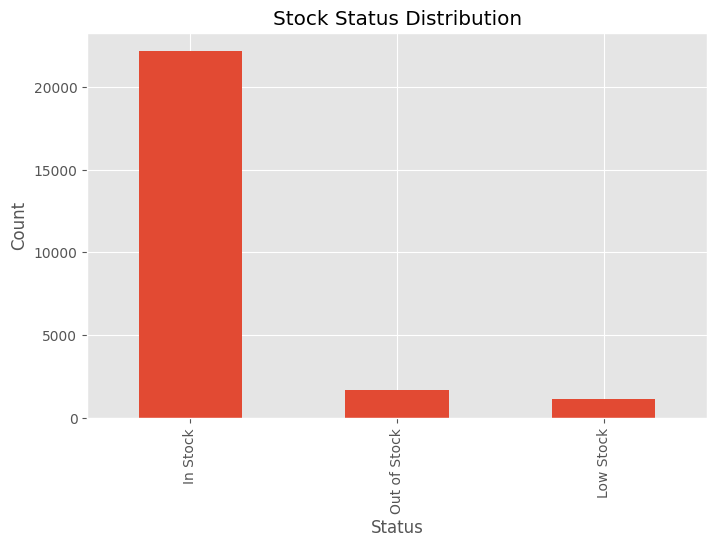

In [25]:
inventory['stock_status'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Stock Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

# Average Expected vs Actual Stock

In [26]:
inventory[
    ['expected_stock','actual_stock']
].mean()

expected_stock    59.53132
actual_stock      40.42132
dtype: float64

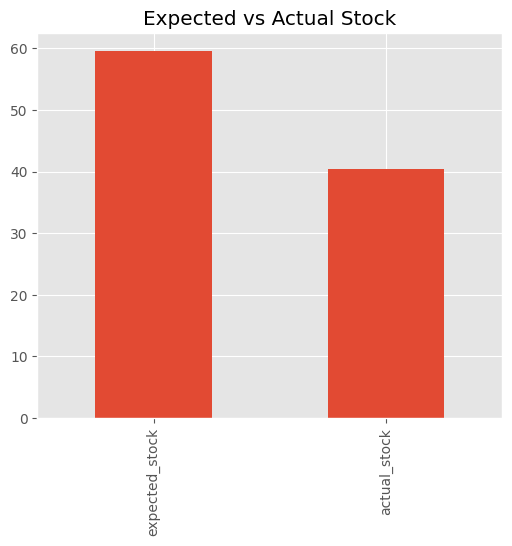

In [27]:
inventory[
    ['expected_stock','actual_stock']
].mean().plot(
    kind='bar',
    figsize=(6,5)
)

plt.title("Expected vs Actual Stock")

plt.show()

# Top 10 Highest Stock Loss

In [28]:
inventory.sort_values(
    'stock_difference',
    ascending=False
).head(10)

,inventory_id,store_id,sku_id,inventory_date,expected_stock,actual_stock,stock_status,stock_difference,stock_loss_percent,inventory_health
13679,INV013680,S028,SKU0180,2026-06-01,59,20,In Stock,39,66.101695,Shortage
11782,INV011783,S024,SKU0283,2026-06-01,87,48,In Stock,39,44.827586,Shortage
2526,INV002527,S006,SKU0027,2026-06-01,43,4,Low Stock,39,90.697674,Shortage
6539,INV006540,S014,SKU0040,2026-06-01,71,32,In Stock,39,54.929577,Shortage
21740,INV021741,S044,SKU0241,2026-06-01,50,11,In Stock,39,78.000000,Shortage
24844,INV024845,S050,SKU0345,2026-06-01,74,35,In Stock,39,52.702703,Shortage
5561,INV005562,S012,SKU0062,2026-06-01,54,15,In Stock,39,72.222222,Shortage
8338,INV008339,S017,SKU0339,2026-06-01,47,8,Low Stock,39,82.978723,Shortage
7763,INV007764,S016,SKU0264,2026-06-01,89,50,In Stock,39,43.820225,Shortage
19303,INV019304,S039,SKU0304,2026-06-01,63,24,In Stock,39,61.904762,Shortage


# Histogram of Actual Stock

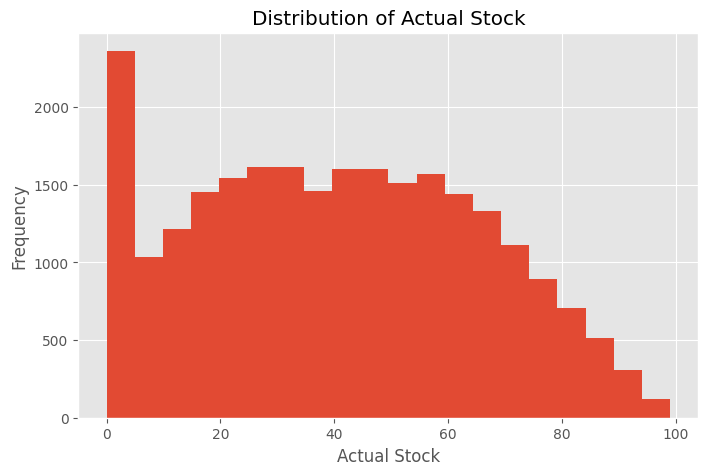

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    inventory['actual_stock'],
    bins=20
)

plt.xlabel("Actual Stock")
plt.ylabel("Frequency")
plt.title("Distribution of Actual Stock")

plt.show()

# Correlation

In [30]:
inventory.select_dtypes(include='number').corr()

,expected_stock,actual_stock,stock_difference,stock_loss_percent
expected_stock,1.000000,0.894926,0.062111,-0.541874
actual_stock,0.894926,1.000000,-0.389768,-0.815784
stock_difference,0.062111,-0.389768,1.000000,0.706364
stock_loss_percent,-0.541874,-0.815784,0.706364,1.000000


Heatmap

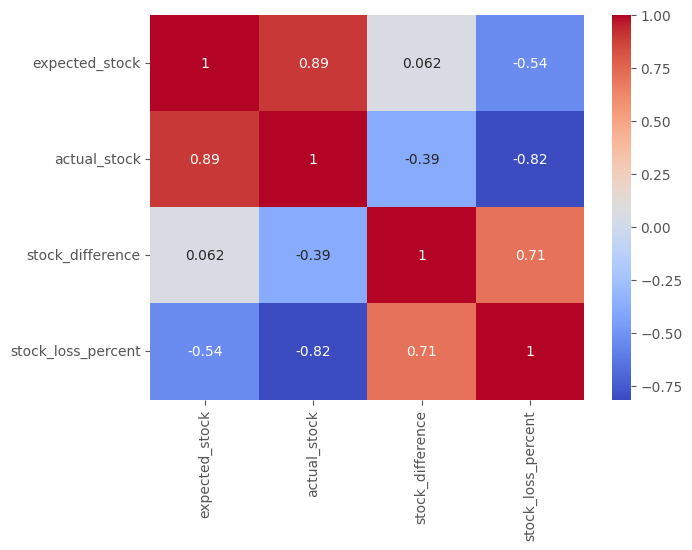

In [31]:
plt.figure(figsize=(7,5))

sns.heatmap(
    inventory.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

# Daily Inventory Trend

In [32]:
daily_inventory = (
    inventory.groupby(
        'inventory_date'
    )[
        ['expected_stock','actual_stock']
    ]
    .sum()
)

daily_inventory.head()

,expected_stock,actual_stock
inventory_date,,
2026-06-01,1488283,1010533


Plot Trend

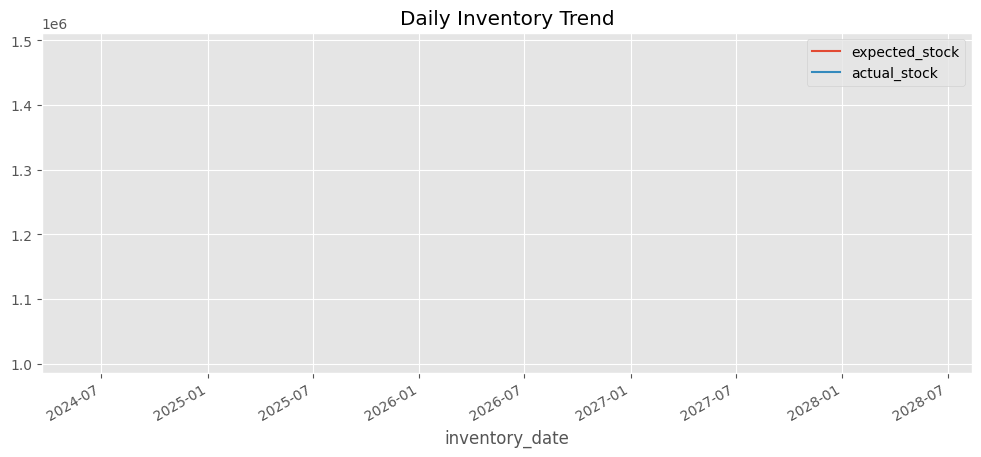

In [33]:
daily_inventory.plot(
    figsize=(12,5)
)

plt.title("Daily Inventory Trend")

plt.show()

# Stock-out Records

In [34]:
stock_out = inventory[
    inventory['actual_stock']==0
]

stock_out.head()

,inventory_id,store_id,sku_id,inventory_date,expected_stock,actual_stock,stock_status,stock_difference,stock_loss_percent,inventory_health
30,INV000031,S001,SKU0031,2026-06-01,30,0,Out of Stock,30,100.0,Shortage
34,INV000035,S001,SKU0035,2026-06-01,21,0,Out of Stock,21,100.0,Shortage
35,INV000036,S001,SKU0036,2026-06-01,21,0,Out of Stock,21,100.0,Shortage
49,INV000050,S001,SKU0050,2026-06-01,23,0,Out of Stock,23,100.0,Shortage
62,INV000063,S001,SKU0063,2026-06-01,29,0,Out of Stock,29,100.0,Shortage


Count

In [35]:
len(stock_out)

1688

Percentage

In [36]:
(
    len(stock_out)
    / len(inventory)
)*100

6.752

# Inventory Leakage

In [37]:
inventory['inventory_leakage'] = (
    inventory['expected_stock']
    - inventory['actual_stock']
)

inventory['inventory_leakage'].sum()

np.int64(477750)

# KPI Summary

In [38]:
print("Total Records:",len(inventory))

print("Average Expected Stock:",
      inventory['expected_stock'].mean())

print("Average Actual Stock:",
      inventory['actual_stock'].mean())

print("Total Inventory Leakage:",
      inventory['inventory_leakage'].sum())

print("Average Stock Loss %:",
      inventory['stock_loss_percent'].mean())

Total Records: 25000
Average Expected Stock: 59.53132
Average Actual Stock: 40.42132
Total Inventory Leakage: 477750
Average Stock Loss %: 37.98894650486422


# Export Clean Inventory Report

In [39]:
inventory.to_csv(
    "../reports/inventory_analysis_report.csv",
    index=False
)